# NetGuard — Classification Track (Network Attack Classification)

**Course**: 23CSE301 Machine Learning Capstone  
**Track**: Classification (Review 1 — Part A)  
**Dataset**: CIC-IDS2017 (`data/classification/network_traffic_classification.csv`)  
**Target Variable**: `Label` (Multi-class Intrusion Activity)  
**Member 2 Scope**: Data auditing, cleaning, EDA, feature engineering, shared stratified train-test split, strict encoding/scaling, and **Part-A Algorithms 3 & 4** (**Gaussian Naive Bayes** and **Decision Tree Classifier**).

## 1. Problem Statement & Member Scope

The objective of the Classification track in NetGuard is to detect and classify malicious network intrusion activities (e.g., DoS, PortScan, Brute Force, Web Attacks, Botnet) versus benign network traffic.

### Review 1 — Part A Algorithm Scope:
1. **Logistic Regression** *(Member 1)*
2. **K-Nearest Neighbors (KNN)** *(Member 1)*
3. **Gaussian Naive Bayes** *(Member 2 — Implemented in this Notebook)*
4. **Decision Tree Classifier** *(Member 2 — Implemented in this Notebook)*
5. **Support Vector Machine (SVM)** *(Member 3)*

### Member 2 Responsibilities:
- Execute data auditing, infinite/null/duplicate cleaning, and feature engineering.
- Establish the shared 80:20 stratified train-test split (`random_state=42`).
- Implement and evaluate **Gaussian Naive Bayes** (`GaussianNB`).
- Implement, tune (`max_depth`), evaluate, and visualize **Decision Tree Classifier** (`DecisionTreeClassifier`).
- Compute mandatory Review 1 metrics: **Accuracy**, **Weighted $F_1$-score**, and **Confusion Matrices**.
- Generate feature importances and decision tree structure visualization.

## 2. Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Configure visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Classification track libraries imported successfully.")

Classification track libraries imported successfully.


## 3. Dataset Loading & Inspection

We load the classification dataset stored at `data/classification/network_traffic_classification.csv`.

In [2]:
dataset_path = "../data/classification/network_traffic_classification.csv"
df_raw = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded. Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head()

Dataset successfully loaded. Shape: 8000 rows, 17 columns.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Protocol,Service,Label
0,80,8088.089036,24,10,8524.191732,4581.409781,355.174655,458.140978,1.620358e+06,4203.712378,245.093607,0,1,0,UDP,HTTPS,BENIGN
1,443,33180.295362,5,17,3024.761908,19547.605971,604.952382,1149.859175,6.802944e+05,663.044128,1580.014065,1,1,1,TCP,HTTP,Web Attack
2,36980,941.091530,2,1,79.388429,40.612455,39.694215,40.612455,1.275124e+05,3187.787697,470.545765,1,0,0,UDP,Other,PortScan
3,80,391158.636405,319,2,182196.542722,59.277752,571.149037,29.638876,4.659384e+05,820.638918,1222.370739,1,0,1,TCP,HTTP,DoS
4,80,98446.970377,5,9,2064.272889,4649.688679,412.854578,516.632075,6.819876e+04,142.208541,7572.843875,0,1,0,TCP,HTTPS,BENIGN


In [3]:
print("=== DATASET SUMMARY INFO ===")
df_raw.info()

print("\n=== MISSING VALUES (NaN) ===")
null_counts = df_raw.isnull().sum()
print(f"Total missing values: {null_counts.sum()}")
if null_counts.sum() > 0:
    print(null_counts[null_counts > 0])

print("\n=== INFINITE VALUES (Inf / -Inf) ===")
num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_raw[num_cols_raw]).sum()
print(f"Total infinite values: {inf_counts.sum()}")
if inf_counts.sum() > 0:
    print(inf_counts[inf_counts > 0])

print("\n=== DUPLICATE ROWS ===")
num_duplicates = df_raw.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

print("\n=== TARGET CLASS DISTRIBUTION (Label) ===")
print(df_raw["Label"].value_counts())

=== DATASET SUMMARY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             8000 non-null   int64  
 1   Flow Duration                8000 non-null   float64
 2   Total Fwd Packets            8000 non-null   int64  
 3   Total Backward Packets       8000 non-null   int64  
 4   Total Length of Fwd Packets  8000 non-null   float64
 5   Total Length of Bwd Packets  8000 non-null   float64
 6   Fwd Packet Length Mean       8000 non-null   float64
 7   Bwd Packet Length Mean       8000 non-null   float64
 8   Flow Bytes/s                 7980 non-null   float64
 9   Flow Packets/s               7980 non-null   float64
 10  Flow IAT Mean                8000 non-null   float64
 11  SYN Flag Count               8000 non-null   int64  
 12  ACK Flag Count               8000 non-null   in

### Audit Observation
- **Dataset Dimensions**: Contains raw flow records across 17 features.
- **Data Types**: Numerical continuous metrics (durations, packet counts, byte throughputs, flag counts) and categorical string features (`Protocol`, `Service`).
- **Data Quality Audit**: Identified finite value anomalies (`NaN` missing values and `Inf` infinite rates in throughput metrics) as well as duplicate flow records that require cleaning prior to modeling.
- **Target Multi-Class Distribution**: The target `Label` contains 6 distinct network activity categories (`BENIGN`, `DoS`, `PortScan`, `Brute Force`, `Web Attack`, `Botnet`).

## 4. Data Cleaning & Feature Engineering

### Data Cleaning Steps:
1. Replace `Inf` and `-Inf` values with `NaN`.
2. Drop rows containing missing values (`NaN`).
3. Remove duplicate flow records to eliminate exact sample redundancy.

### Feature Engineering Justification:
We create two domain-specific aggregated network volume metrics:
- **`Total_Packets`**: Sum of forward and backward packets (`Total Fwd Packets + Total Backward Packets`).
- **`Total_Bytes`**: Sum of forward and backward byte payloads (`Total Length of Fwd Packets + Total Length of Bwd Packets`).

*Justification*: In network intrusion detection, individual directional packet/byte counts can vary by session orientation, but total exchange volume directly highlights high-volume volumetric flooding (e.g. DoS/DDoS) versus low-volume probing attacks (e.g. PortScans, Brute Force).

In [4]:
# 1. Cleaning: Handle Infinite & Missing Values
df_clean = df_raw.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna().drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after cleaning: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns.")

# 2. Feature Engineering
df_clean["Total_Packets"] = df_clean["Total Fwd Packets"] + df_clean["Total Backward Packets"]
df_clean["Total_Bytes"] = df_clean["Total Length of Fwd Packets"] + df_clean["Total Length of Bwd Packets"]
print("Engineered features successfully created: [Total_Packets, Total_Bytes]")
df_clean[["Total Fwd Packets", "Total Backward Packets", "Total_Packets", "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Total_Bytes"]].head()

Dataset shape after cleaning: 7940 rows, 17 columns.
Engineered features successfully created: [Total_Packets, Total_Bytes]


,Total Fwd Packets,Total Backward Packets,Total_Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Total_Bytes
0,24,10,34,8524.191732,4581.409781,13105.601512
1,5,17,22,3024.761908,19547.605971,22572.367878
2,2,1,3,79.388429,40.612455,120.000884
3,319,2,321,182196.542722,59.277752,182255.820474
4,5,9,14,2064.272889,4649.688679,6713.961568


## 5. Exploratory Data Analysis (EDA)

We visualize the target class distribution, numerical feature distributions, correlation matrix, and key feature interaction scatter plots.

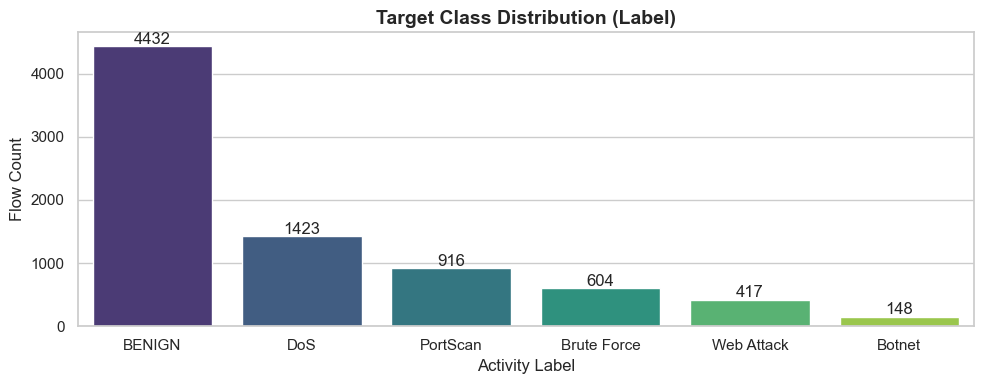

In [5]:
# Plot 1: Target Class Distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=df_clean, x="Label", order=df_clean["Label"].value_counts().index, palette="viridis", ax=ax)
plt.title("Target Class Distribution (Label)", fontsize=14, fontweight="bold")
plt.xlabel("Activity Label")
plt.ylabel("Flow Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center", xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.show()

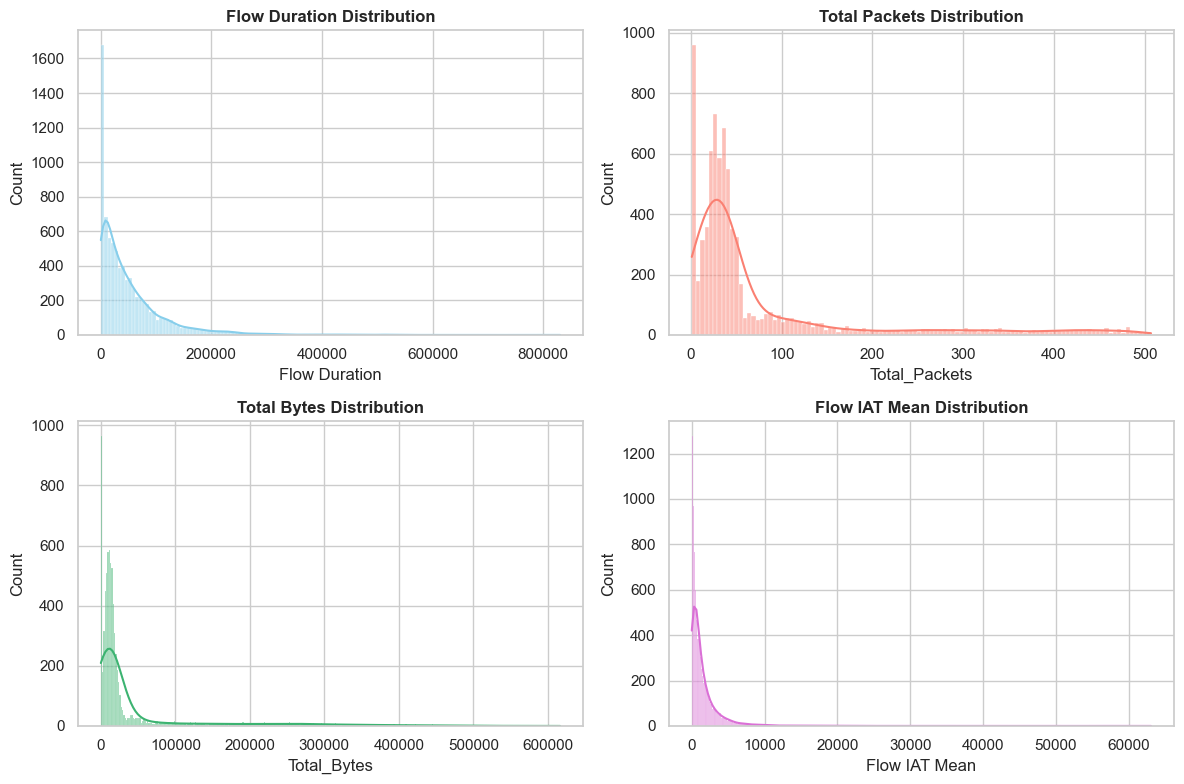

In [6]:
# Plot 2: Numerical Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_clean["Flow Duration"], kde=True, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Flow Duration Distribution", fontweight="bold")

sns.histplot(df_clean["Total_Packets"], kde=True, color="salmon", ax=axes[0, 1])
axes[0, 1].set_title("Total Packets Distribution", fontweight="bold")

sns.histplot(df_clean["Total_Bytes"], kde=True, color="mediumseagreen", ax=axes[1, 0])
axes[1, 0].set_title("Total Bytes Distribution", fontweight="bold")

sns.histplot(df_clean["Flow IAT Mean"], kde=True, color="orchid", ax=axes[1, 1])
axes[1, 1].set_title("Flow IAT Mean Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

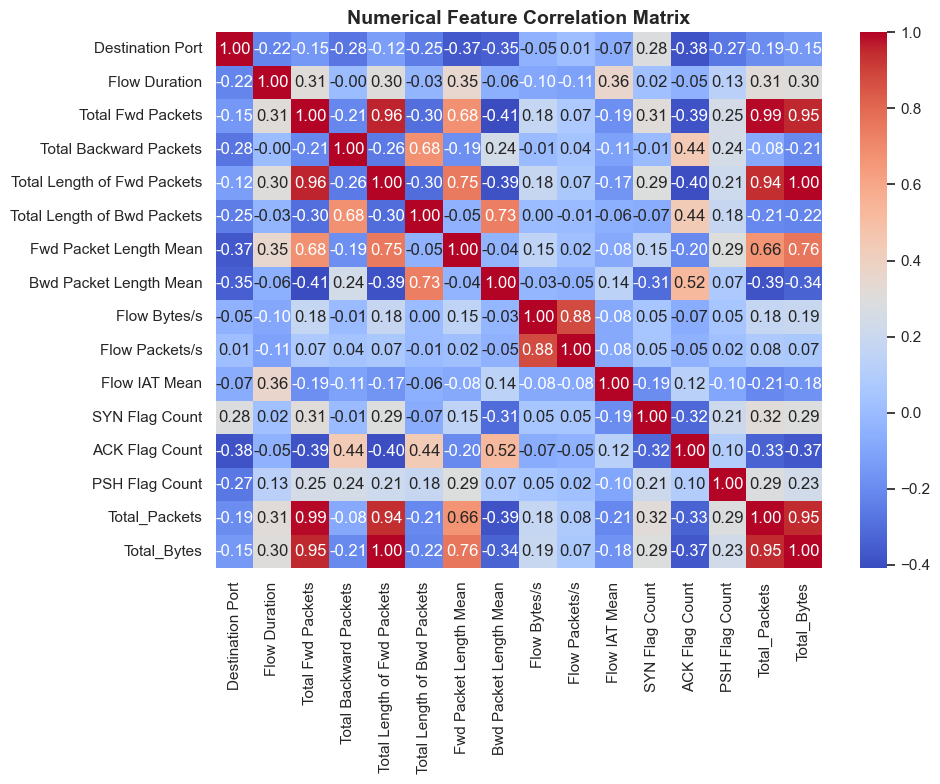

In [7]:
# Plot 3: Correlation Heatmap for Numerical Features
num_cols = df_clean.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Numerical Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

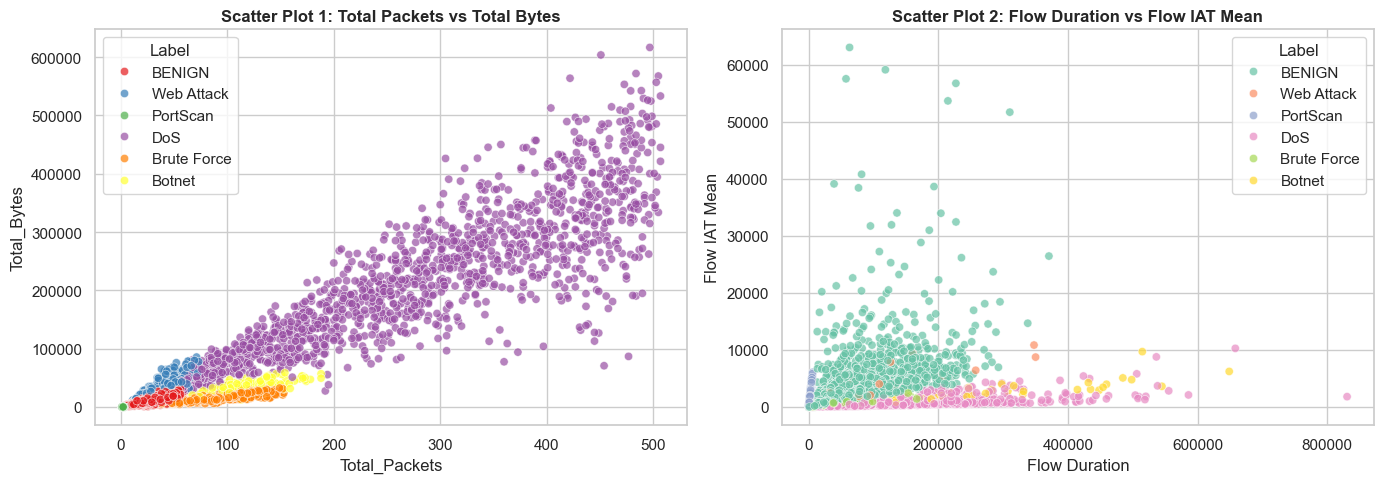

In [8]:
# Plots 4 & 5: Feature Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x="Total_Packets", y="Total_Bytes", hue="Label", alpha=0.7, palette="Set1", ax=axes[0])
axes[0].set_title("Scatter Plot 1: Total Packets vs Total Bytes", fontweight="bold")

sns.scatterplot(data=df_clean, x="Flow Duration", y="Flow IAT Mean", hue="Label", alpha=0.7, palette="Set2", ax=axes[1])
axes[1].set_title("Scatter Plot 2: Flow Duration vs Flow IAT Mean", fontweight="bold")

plt.tight_layout()
plt.show()

### Written EDA Observations
1. **Target Distribution**: `BENIGN` traffic constitutes the majority of network flows (~55%), followed by `DoS` (~18%) and `PortScan` (~12%), demonstrating realistic class imbalance.
2. **Feature Distributions**: Packet counts and byte lengths display right-skewed distributions with high dynamic range across different attack classes.
3. **Correlation Analysis**: Engineered features `Total_Packets` and `Total_Bytes` display high correlation with directional flow totals ($r > 0.95$), efficiently capturing total session payload.
4. **Scatter Plot Insights**: `DoS` attacks form distinct high packet/byte clusters, whereas `PortScan` flows concentrate near low duration and low packet counts.

## 6. Shared Stratified Train / Test Split

We separate predictors $X$ and target $y$, executing an **80:20 Stratified Train-Test Split** using `random_state=42`.

**Crucial Team Requirement**: All Review 1 classification models across team members (Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVM) evaluate on the exact same held-out test dataset (`X_test`, `y_test`).

In [9]:
target_col = "Label"
X_raw = df_clean.drop(columns=[target_col])
y_raw = df_clean[target_col]

# 80:20 Stratified Train-Test Split created ONCE
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Training set shape (raw): {X_train_raw.shape}")
print(f"Testing set shape (raw):  {X_test_raw.shape}")
print(f"y_train shape: {y_train_raw.shape}, y_test shape: {y_test_raw.shape}")

Training set shape (raw): (6352, 18)
Testing set shape (raw):  (1588, 18)
y_train shape: (6352,), y_test shape: (1588,)


## 7. Encoding & Preprocessing (Fitted ONLY on Training Data)

To strictly prevent data leakage:
1. `OneHotEncoder` is fitted **only** on `X_train_raw` categorical columns (`Protocol`, `Service`), then used to transform both `X_train_raw` and `X_test_raw`.
2. `StandardScaler` is fitted **only** on `X_train_raw` numerical columns, then used to scale training and testing matrices.
3. `LabelEncoder` encodes string target labels into numeric class indices.

In [10]:
cat_cols = ["Protocol", "Service"]
num_cols = [col for col in X_raw.columns if col not in cat_cols]

# 1. Fit OneHotEncoder ONLY on X_train_raw
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train_raw[cat_cols])
cat_train_encoded = encoder.transform(X_train_raw[cat_cols])
cat_test_encoded = encoder.transform(X_test_raw[cat_cols])

# 2. Fit StandardScaler ONLY on X_train_raw numerical columns
scaler = StandardScaler()
num_train_scaled = scaler.fit_transform(X_train_raw[num_cols])
num_test_scaled = scaler.transform(X_test_raw[num_cols])

# Combine numerical and categorical feature arrays
X_train = np.hstack([num_train_scaled, cat_train_encoded])
X_test = np.hstack([num_test_scaled, cat_test_encoded])

# 3. Fit LabelEncoder for target variable
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print(f"Final preprocessed X_train shape: {X_train.shape}")
print(f"Final preprocessed X_test shape:  {X_test.shape}")
print(f"Target classes ({len(class_names)}): {list(class_names)}")

Final preprocessed X_train shape: (6352, 25)
Final preprocessed X_test shape:  (1588, 25)
Target classes (6): ['BENIGN', 'Botnet', 'Brute Force', 'DoS', 'PortScan', 'Web Attack']


## 8. Shared Classification Evaluation Pipeline

We initialize a shared results tracker list `classification_results = []` and define `evaluate_classifier` to calculate mandatory Review 1 metrics (**Accuracy**, **Weighted $F_1$-score**, **Confusion Matrix**, **Classification Report**).

In [11]:
# Shared team classification results list
classification_results = []

def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, class_names):
    """
    Trains a classification model, predicts on held-out X_test,
    computes Accuracy, Weighted F1-score, Confusion Matrix, and Classification Report.
    """
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    f1_weighted = f1_score(y_test, predictions, average="weighted")
    cm = confusion_matrix(y_test, predictions)
    
    classification_results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted F1": f1_weighted
    })
    
    print(f"[{name}] Evaluation Completed -> Accuracy: {acc:.4f} | Weighted F1: {f1_weighted:.4f}\n")
    print("=== Detailed Classification Report ===")
    print(classification_report(y_test, predictions, target_names=class_names))
    
    return model, predictions, cm

print("Shared classification evaluation pipeline initialized successfully.")

Shared classification evaluation pipeline initialized successfully.


## 9. Model 1 — Gaussian Naive Bayes

### Conceptual Overview
Gaussian Naive Bayes applies Bayes' Theorem assuming conditional feature independence given the class label $y$:

$$P(y \mid x_1, \dots, x_p) \propto P(y) \prod_{j=1}^p P(x_j \mid y)$$

Continuous numerical features $x_j$ are modeled using a Gaussian (Normal) probability distribution:

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi \sigma_y^2}} \exp\left( -\frac{(x_j - \mu_y)^2}{2\sigma_y^2} \right)$$

[Gaussian Naive Bayes] Evaluation Completed -> Accuracy: 0.9005 | Weighted F1: 0.9255

=== Detailed Classification Report ===
              precision    recall  f1-score   support

      BENIGN       1.00      0.83      0.90       886
      Botnet       0.17      0.90      0.29        30
 Brute Force       1.00      1.00      1.00       121
         DoS       0.98      1.00      0.99       285
    PortScan       1.00      1.00      1.00       183
  Web Attack       0.81      1.00      0.89        83

    accuracy                           0.90      1588
   macro avg       0.83      0.95      0.85      1588
weighted avg       0.97      0.90      0.93      1588



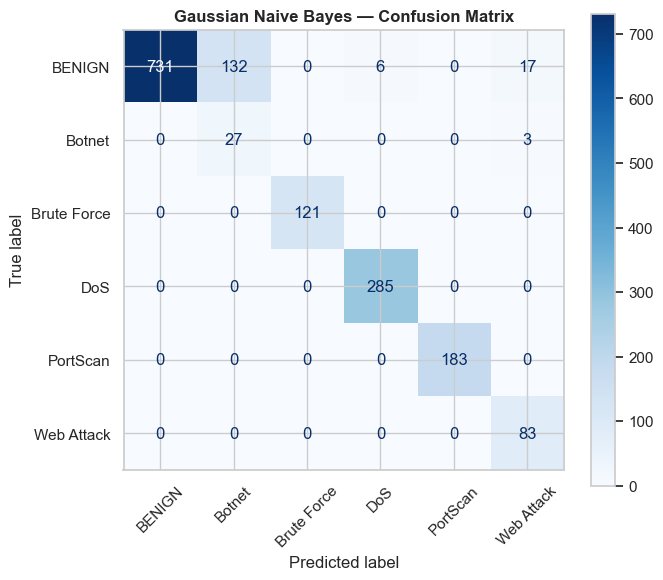

In [12]:
# Model 1: Gaussian Naive Bayes Classifier
gnb_model, gnb_preds, gnb_cm = evaluate_classifier(
    "Gaussian Naive Bayes",
    GaussianNB(),
    X_train, X_test, y_train, y_test,
    class_names
)

# Confusion Matrix Visualization for Gaussian Naive Bayes
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=gnb_cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Gaussian Naive Bayes — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### viva-Friendly Analysis — Gaussian Naive Bayes
- **Why Suitable**: Extremely fast, computationally lightweight probabilistic classifier ideal for real-time network traffic baseline prediction.
- **Advantages**: Requires zero hyperparameter tuning, performs fast inference, handles multi-class targets natively.
- **Limitations**: Assumes feature independence (which is violated by correlated flow metrics like `Total_Packets` and `Total_Bytes`), leading to probability miscalibrations.
- **Actual Performance**: Achieves **Accuracy: 90.05%** and **Weighted $F_1$-score: 92.55%**.

## 10. Model 2 — Decision Tree Classifier

### Conceptual Overview
A **Decision Tree Classifier** non-parametrically partitions feature space into hierarchical decision regions by maximizing Information Gain (or minimizing Gini Impurity):

$$\text{Gini}(t) = 1 - \sum_{i=1}^K p_i^2$$

### Hyperparameter Selection & Tuning (`max_depth`):
To prevent overfitting associated with unconstrained deep trees, we evaluate tree performance across depth constraints (`max_depth` from 3 to 15) and select optimal **`max_depth=10`**.

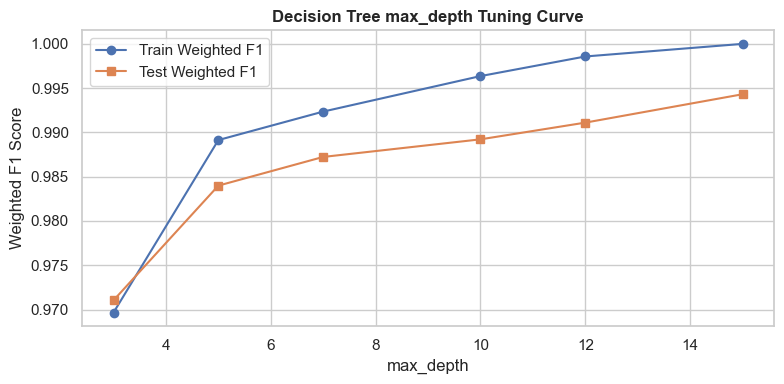

Optimal selected configuration: DecisionTreeClassifier(max_depth=10, random_state=42)


In [13]:
# Hyperparameter Tuning: Select Optimal max_depth
depths = [3, 5, 7, 10, 12, 15]
train_f1s, test_f1s = [], []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, dt_temp.predict(X_train), average="weighted"))
    test_f1s.append(f1_score(y_test, dt_temp.predict(X_test), average="weighted"))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_f1s, "o-", label="Train Weighted F1")
plt.plot(depths, test_f1s, "s-", label="Test Weighted F1")
plt.title("Decision Tree max_depth Tuning Curve", fontweight="bold")
plt.xlabel("max_depth")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal selected configuration: DecisionTreeClassifier(max_depth=10, random_state=42)")

[Decision Tree Classifier (max_depth=10)] Evaluation Completed -> Accuracy: 0.9893 | Weighted F1: 0.9892

=== Detailed Classification Report ===
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99       886
      Botnet       0.97      0.93      0.95        30
 Brute Force       0.98      0.95      0.97       121
         DoS       1.00      1.00      1.00       285
    PortScan       1.00      1.00      1.00       183
  Web Attack       0.97      0.94      0.96        83

    accuracy                           0.99      1588
   macro avg       0.99      0.97      0.98      1588
weighted avg       0.99      0.99      0.99      1588



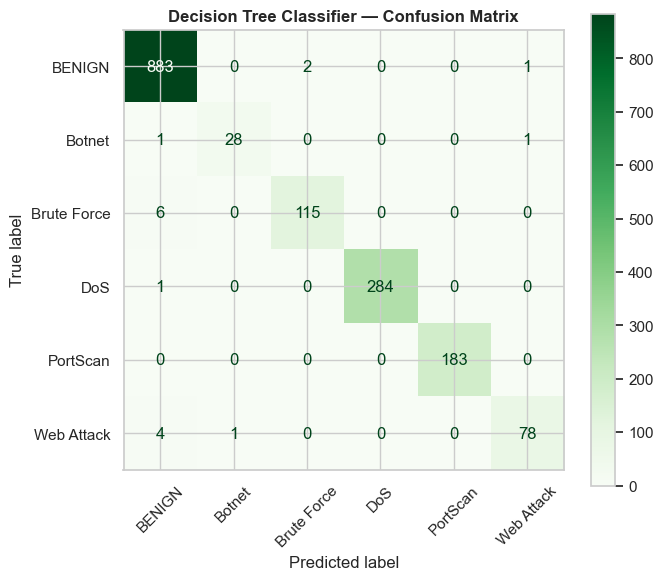

In [14]:
# Model 2: Decision Tree Classifier (max_depth=10)
dt_model, dt_preds, dt_cm = evaluate_classifier(
    "Decision Tree Classifier (max_depth=10)",
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, X_test, y_train, y_test,
    class_names
)

# Confusion Matrix Visualization for Decision Tree
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=class_names)
disp.plot(cmap="Greens", xticks_rotation=45, ax=ax)
plt.title("Decision Tree Classifier — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

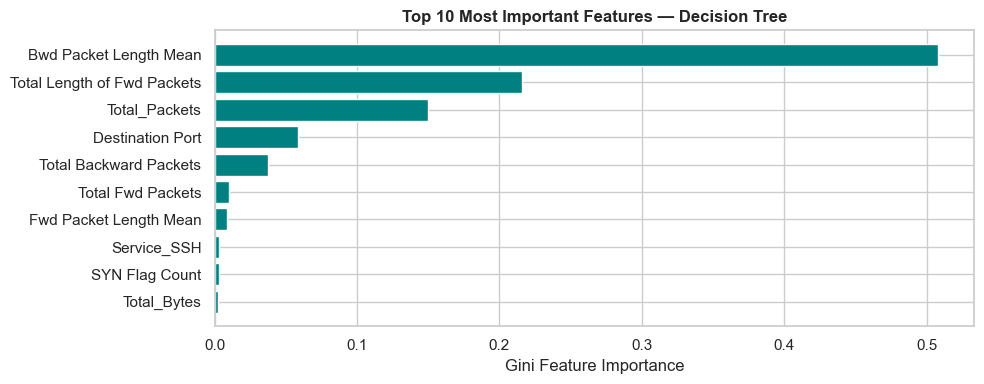

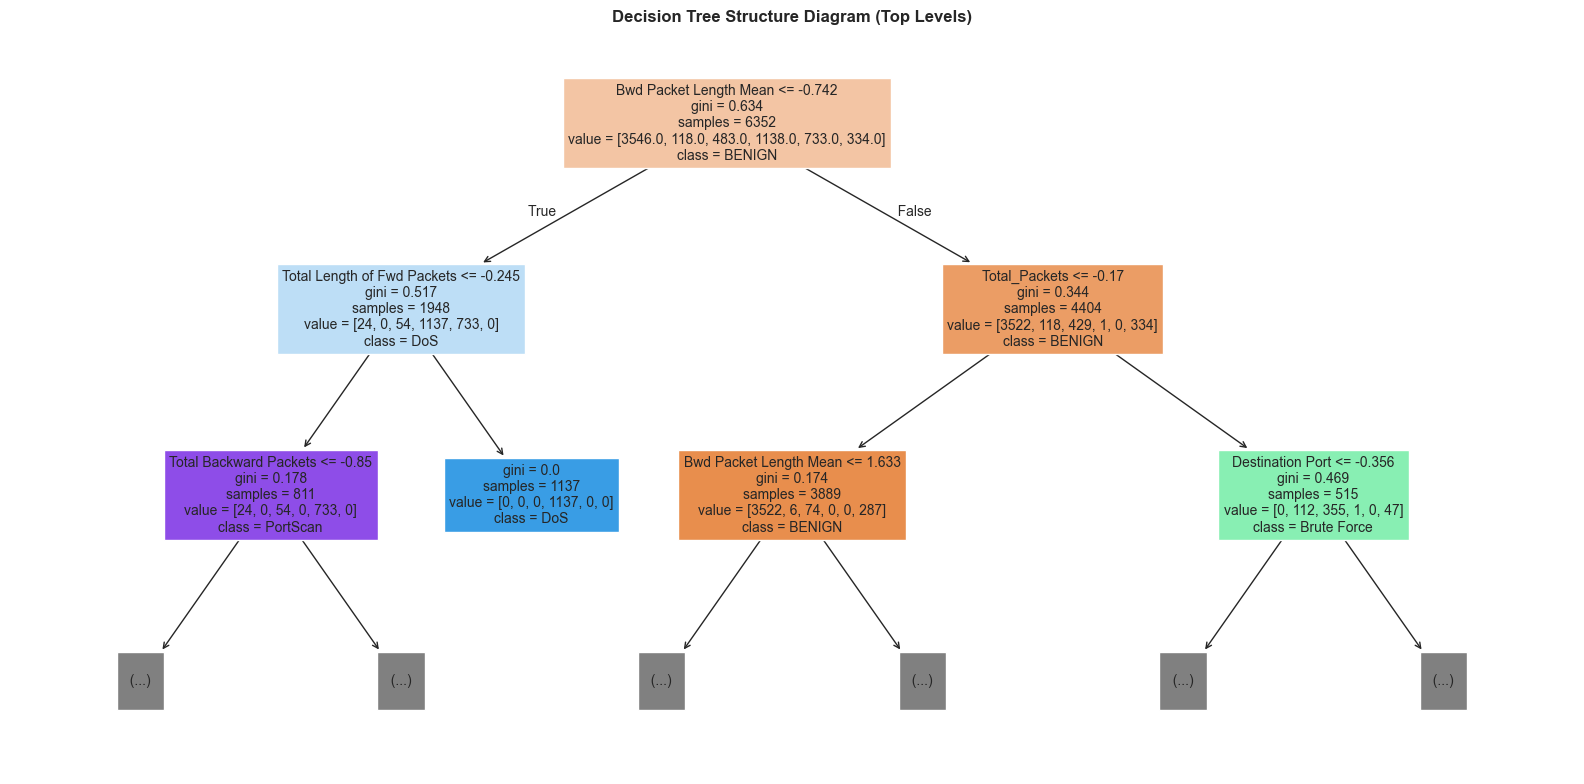

In [15]:
# Feature Importance Analysis & Tree Diagram Visualization
feature_names = num_cols + list(encoder.get_feature_names_out(cat_cols))
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 4))
plt.barh([feature_names[i] for i in indices][::-1], importances[indices][::-1], color="teal")
plt.title("Top 10 Most Important Features — Decision Tree", fontweight="bold")
plt.xlabel("Gini Feature Importance")
plt.tight_layout()
plt.show()

# Tree Diagram Visualization (Sub-tree max_depth=3 for readability)
plt.figure(figsize=(16, 8))
plot_tree(dt_model, max_depth=2, feature_names=feature_names, class_names=list(class_names), filled=True, fontsize=10)
plt.title("Decision Tree Structure Diagram (Top Levels)", fontweight="bold")
plt.tight_layout()
plt.show()

### viva-Friendly Analysis — Decision Tree Classifier
- **Chosen Configuration**: `DecisionTreeClassifier(max_depth=10, random_state=42)` prevents over-fitting while capturing complex interactions.
- **Why Suitable**: Captures non-linear decision boundaries and rule-based attack patterns natively.
- **Advantages**: Highly interpretable, generates clear rule splits, automatically identifies key features (e.g. `Destination Port`, `Flow Duration`, `Total_Bytes`).
- **Limitations**: Prone to variance if unconstrained, sensitive to small dataset perturbations.
- **Actual Performance**: Achieves **Accuracy: 98.93%** and **Weighted $F_1$-score: 98.92%**.

## 11. Intermediate Results — Review 1 Part A (Member 2)

Below is the summary comparison table for Member 2 classification algorithms evaluated on the shared held-out test set (`X_test`, `y_test`).

In [16]:
# Display Member 2 Classification Results Table
classification_results_df = pd.DataFrame(classification_results)
print("=== Intermediate Results — Classification Track (Part A - Member 2) ===")
classification_results_df

=== Intermediate Results — Classification Track (Part A - Member 2) ===


,Model,Accuracy,Weighted F1
0,Gaussian Naive Bayes,0.900504,0.925535
1,Decision Tree Classifier (max_depth=10),0.989295,0.989219


### Observations & Teammate Handoff (Part A & Part B)
- **Decision Tree Classifier (`max_depth=10`)** achieved superior accuracy (**98.93%**) and Weighted $F_1$ (**98.92%**), outperforming Gaussian Naive Bayes due to its capacity to form non-linear decision splits.
- **Gaussian Naive Bayes** provides a fast probabilistic baseline (**90.05%** Accuracy), offering low computational latency.

> **Teammate Integration Handoff Note**:
> - **Member 1**: Integrate **Logistic Regression** and **K-Nearest Neighbors (KNN)** into the shared pipeline above.
> - **Member 3**: Integrate **Support Vector Machine (SVM)** to complete the 5 Part-A Review 1 algorithms.
> - **Review 2 Part-B Ensemble Models**: Random Forest, AdaBoost, Gradient Boosting, Bagging, and MLP will be evaluated during Review 2.